
# SVM Kernels Benchmark

This notebook compares **Support Vector Machine (SVM)** classifiers with different kernel functions on classic benchmark datasets using **scikit-learn**.

### What you'll get
- Quick switch between datasets: `iris`, `wine`, `breast_cancer`, `digits`
- Train/test split with **standardization**
- Evaluation of kernels: **linear**, **poly**, **rbf**, **sigmoid**
- Metrics: accuracy, F1 (macro), precision/recall, confusion matrix, classification report
- **PCA 2D** visualization of decision regions (approx.) and support vectors
- Optional **GridSearchCV** for hyperparameter tuning
- Learning curve and validation curve helpers

In [12]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, validation_curve
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

#@param tells Colab: “make this variable adjustable in the UI.”
*   ["iris", "wine", "breast_cancer", "digits"] is a drop-down menu with those four choices.
*   "iris" is the default value

In [13]:
# Choose dataset
dataset_name = "wine" # @param ["iris","wine","breast_cancer","digits"]

def load_dataset(name):
    if name == "iris":
        data = datasets.load_iris()
    elif name == "wine":
        data = datasets.load_wine()
    elif name == "breast_cancer":
        data = datasets.load_breast_cancer()
    elif name == "digits":
        data = datasets.load_digits()
    else:
        raise ValueError("Unknown dataset")
    X = data.data
    y = data.target
    feature_names = getattr(data, "feature_names", [f"f{i}" for i in range(X.shape[1])])
    target_names = getattr(data, "target_names", [str(i) for i in np.unique(y)])
    return X, y, feature_names, target_names

X, y, feature_names, target_names = load_dataset(dataset_name)
print(f"Dataset: {dataset_name} | Samples: {X.shape[0]} | Features: {X.shape[1]} | Classes: {len(np.unique(y))}")


Dataset: iris | Samples: 150 | Features: 4 | Classes: 3


In [3]:

# Split data
test_size = 0.25  #@param {type:"slider", min:0.1, max:0.5, step:0.05}
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (112, 4), Test: (38, 4)


In [4]:

#@title Evaluate multiple kernels
from collections import OrderedDict

def evaluate_kernels(X_train, X_test, y_train, y_test):
    results = []
    models = OrderedDict({
        "linear": SVC(kernel="linear", C=1.0),
        "poly":   SVC(kernel="poly", degree=3, C=1.0, gamma="scale"),
        "rbf":    SVC(kernel="rbf", C=1.0, gamma="scale"),
        "sigmoid":SVC(kernel="sigmoid", C=1.0, gamma="scale")
    })
    for name, model in models.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average="macro")
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro")
        results.append({
            "kernel": name,
            "accuracy": acc,
            "f1_macro": f1m,
            "precision_macro": prec,
            "recall_macro": rec,
            "model": pipe
        })
    return pd.DataFrame(results)

results_df = evaluate_kernels(X_train, X_test, y_train, y_test)
results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)


,kernel,accuracy,f1_macro,precision_macro,recall_macro,model
0,linear,0.973684,0.974321,0.976190,0.974359,"(StandardScaler(), SVC(kernel='linear'))"
1,rbf,0.947368,0.948718,0.948718,0.948718,"(StandardScaler(), SVC())"
2,poly,0.894737,0.894949,0.921569,0.897436,"(StandardScaler(), SVC(kernel='poly'))"
3,sigmoid,0.894737,0.896825,0.903030,0.897436,"(StandardScaler(), SVC(kernel='sigmoid'))"


Best kernel: linear
    kernel  accuracy  f1_macro  precision_macro  recall_macro
0   linear  0.973684  0.974321         0.976190      0.974359
1     poly  0.894737  0.894949         0.921569      0.897436
2      rbf  0.947368  0.948718         0.948718      0.948718
3  sigmoid  0.894737  0.896825         0.903030      0.897436


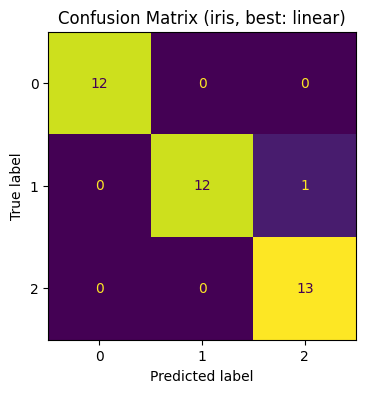


Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [5]:

#@title Pick best kernel & show confusion matrix
best_idx = results_df["accuracy"].idxmax()
best_row = results_df.loc[best_idx]
best_model = best_row["model"]
print("Best kernel:", best_row["kernel"])
print(results_df[["kernel","accuracy","f1_macro","precision_macro","recall_macro"]])

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False)
plt.title(f"Confusion Matrix ({dataset_name}, best: {best_row['kernel']})")
plt.show()

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=[str(t) for t in np.unique(y)]))


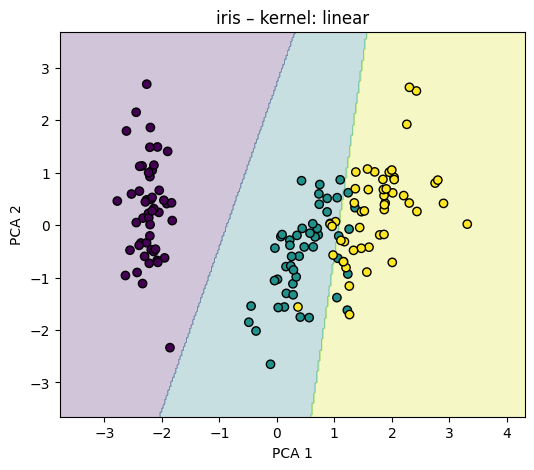

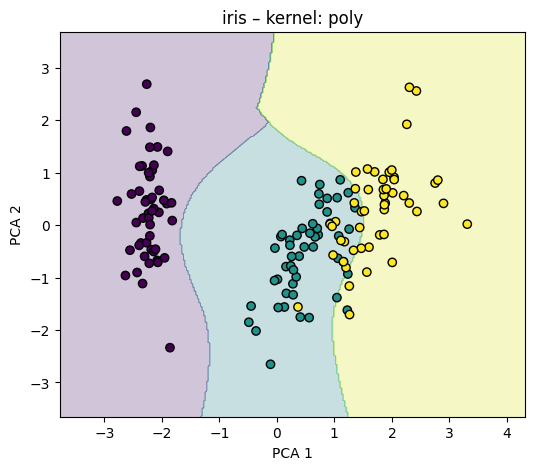

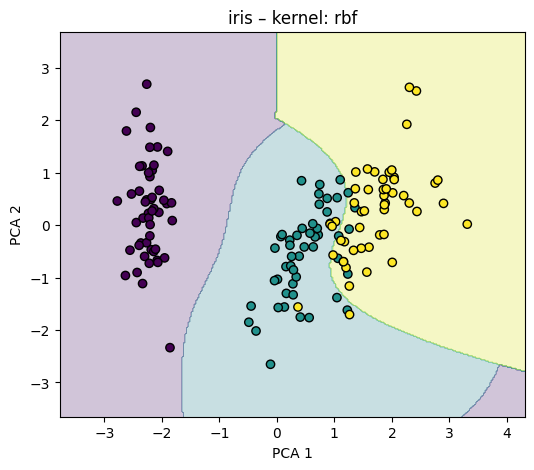

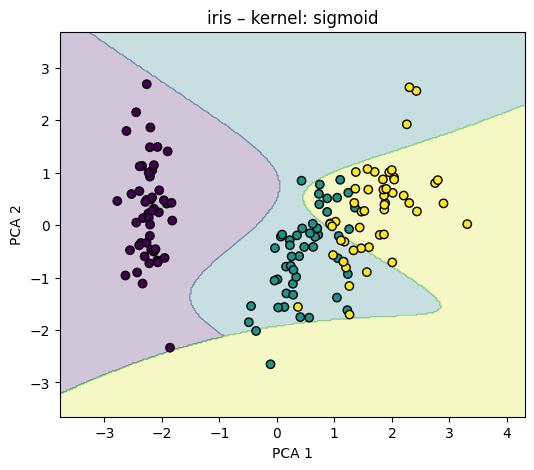

In [6]:

#@title PCA 2D decision regions (approx.) for each kernel
def plot_decision_regions(model_pipe, X, y, title):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(StandardScaler().fit_transform(X))
    x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    # Train a clone on the PCA-projected data for visualization
    from sklearn.base import clone
    clf = clone(model_pipe.named_steps["clf"])
    pipe2 = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    pipe2.fit(X2, y)
    Z = pipe2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6,5))
    ax.contourf(xx, yy, Z, alpha=0.25)
    scatter = ax.scatter(X2[:,0], X2[:,1], c=y, edgecolor="k")
    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    plt.show()

for i, row in results_df.iterrows():
    plot_decision_regions(row["model"], X, y, f"{dataset_name} – kernel: {row['kernel']}")


In [8]:

#@title Optional: GridSearchCV for best kernel (RBF as example)
run_grid_search = True  #@param {type:"boolean"}

if run_grid_search:
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf"))])
    param_grid = {
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", 0.01, 0.1, 1]
    }
    gs = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)
    print("Best params:", gs.best_params_)
    print("Best CV accuracy:", gs.best_score_)
    test_acc = gs.score(X_test, y_test)
    print("Test accuracy:", test_acc)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'clf__C': 1, 'clf__gamma': 0.1}
Best CV accuracy: 0.9640316205533598
Test accuracy: 0.9210526315789473


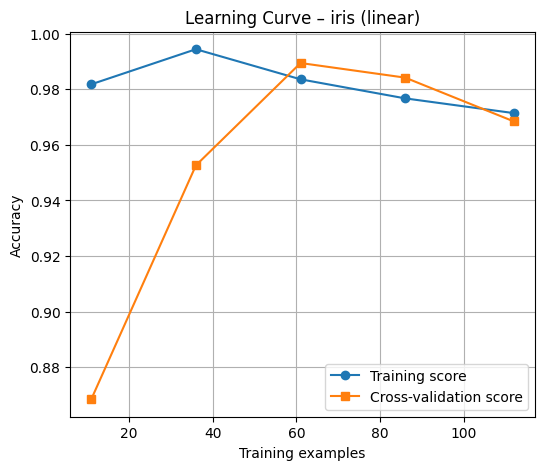

In [9]:

#@title Learning Curve (best kernel)
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=5, test_size=0.25, random_state=42)
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring="accuracy"
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(6,5))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, test_mean, marker="s", label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve – {dataset_name} ({best_row['kernel']})")
plt.legend()
plt.grid(True)
plt.show()


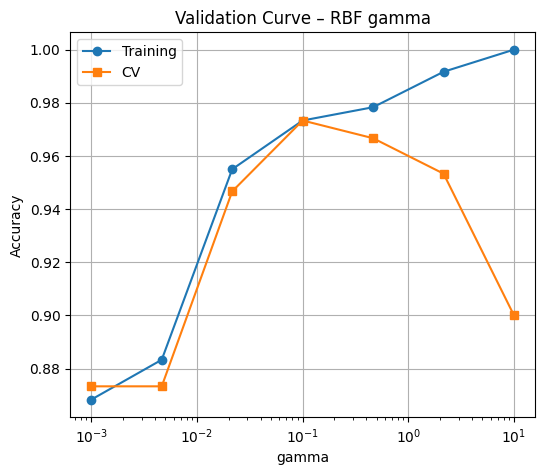

In [10]:

#@title Validation Curve (RBF gamma)
param_range = np.logspace(-3, 1, 7)
pipe = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", C=1.0))])
train_scores, test_scores = validation_curve(
    pipe, X, y, param_name="clf__gamma", param_range=param_range, cv=5, scoring="accuracy", n_jobs=-1
)
plt.figure(figsize=(6,5))
plt.semilogx(param_range, train_scores.mean(axis=1), marker="o", label="Training")
plt.semilogx(param_range, test_scores.mean(axis=1), marker="s", label="CV")
plt.xlabel("gamma")
plt.ylabel("Accuracy")
plt.title("Validation Curve – RBF gamma")
plt.legend()
plt.grid(True)
plt.show()



## Notes
- **Linear** kernel often works well for linearly separable or high-dimensional sparse data.
- **Polynomial** kernel can capture curved boundaries; degree controls complexity.
- **RBF** is usually a strong default; tune `C` and `gamma`.
- **Sigmoid** behaves like a neural network activation; performance can vary.

You can toggle datasets at the top and optionally enable GridSearch for tuning.
